# 트랜스포머 기반 챗봇

# 0. 라이브러리 import 및 setting

In [1]:
import re
import os
import random
import math

import numpy as np
import pandas as pd
import torch
import sentencepiece as spm
from nltk.translate.bleu_score import sentence_bleu
from nltk.translate.bleu_score import SmoothingFunction
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from konlpy.tag import Mecab
from collections import Counter

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

print(torch.__version__)

2.7.1+cu126


In [2]:
DATA_DIR = os.path.join(os.getcwd(), "data")
MODEL_DIR = os.path.join(os.getcwd(), "models")

print(DATA_DIR)
print(MODEL_DIR)

/home/minkyujeong/work/DeepDive/ch6_transformer/data
/home/minkyujeong/work/DeepDive/ch6_transformer/models


In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda


In [4]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import logging

In [5]:
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()

print(f"설정된 폰트: {fontprop.get_name()}")

설정된 폰트: NanumBarunGothic


# 1. 데이터 준비

In [6]:
raw_data = pd.read_csv(os.path.join(DATA_DIR, "ChatbotData.csv"))

print("Data Size:", len(raw_data))
raw_data.head()

Data Size: 11823


,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


## 1.1. 데이터 분석 및 전처리

### 1.1.1. 중복 샘플 확인

In [7]:
print("전체 샘플 수: ", len(raw_data))
print('Q열에서 중복을 배제한 유일한 샘플의 수 :', raw_data['Q'].nunique())
print('A열에서 중복을 배제한 유일한 샘플의 수 :', raw_data['A'].nunique())

전체 샘플 수:  11823
Q열에서 중복을 배제한 유일한 샘플의 수 : 11662
A열에서 중복을 배제한 유일한 샘플의 수 : 7779


In [8]:
print("Q만 중복인 데이터: ", raw_data.duplicated(subset=['Q'], keep=False).sum())
raw_data[raw_data.duplicated(subset=['Q'], keep=False)].sort_values(by='Q').head(6)

Q만 중복인 데이터:  317


,Q,A,label
5316,2년 가량의 연애,안 좋은 기억보다 좋은 기억이 더 많았으면 좋겠네요.,1
8868,2년 가량의 연애,딱 잘 만났네요.,2
8901,가을 타나 봐.,외로운 옆구리를 채워보아요.,2
8902,가을 타나 봐.,혼자는 외로운 계절이죠.,2
5439,간단하게 사랑이라는건.,여러번 해도 어려워요.,1
5438,간단하게 사랑이라는건.,간단하지 않은 것.,1


In [9]:
print("A만 중복인 데이터: ", raw_data.duplicated(subset=['A'], keep=False).sum())
raw_data[raw_data.duplicated(subset=['A'], keep=False)].sort_values(by='A').head(6)

A만 중복인 데이터:  6978


,Q,A,label
1918,반배정 망했어,1년 힘내요.,0
1919,반배정부터 올해 끝났다.,1년 힘내요.,0
11522,짝녀가 좋아하는거 눈치 1도 못챔.,1은 알게 해야죠.,2
11390,짝남이 내가 좋아하는걸 1도 몰라.,1은 알게 해야죠.,2
5016,한복 맞출까 빌릴까,2번 이상 입을 일이 있으면 맞추세요.,0
5017,한복 빌려도 예쁠까,2번 이상 입을 일이 있으면 맞추세요.,0


In [10]:
print("Q, A 둘다 중복인 데이터: ", raw_data.duplicated(subset=['Q', 'A'], keep=False).sum())
raw_data[raw_data.duplicated(subset=['Q', 'A'], keep=False)].sort_values(by='Q').head(6)

Q, A 둘다 중복인 데이터:  146


,Q,A,label
152,결혼이나 하지 왜 자꾸 나한테 화 내냐구!,힘들겠네요.,0
5527,결혼이나 하지 왜 자꾸 나한테 화 내냐구!,힘들겠네요.,1
5537,고백하고 후회하면 어떡하지,후회는 후회를 낳을뿐이에요. 용기 내세요.,1
189,고백하고 후회하면 어떡하지,후회는 후회를 낳을뿐이에요. 용기 내세요.,0
226,공부는 내 체질이 아닌 것 같아,확신이 없나봐요.,0
5542,공부는 내 체질이 아닌 것 같아,확신이 없나봐요.,1


In [11]:
raw_data.drop_duplicates(subset=['Q', 'A'], inplace=True)
print('전체 샘플수 :', (len(raw_data)))

전체 샘플수 : 11750


- Q만 중복되는 경우: 같은 상황(Q)에서 다양한 응답(A) 가능  
- A만 중복되는 경우: 같은 응답(A)도 다른 상황(Q)에서 사용될 수 있음  
- Q,A 모두 중복인 경우 validation, test data에 나눠지면 data leakage가 되므로 삭제

### 1.1.2. 결측치 확인

In [12]:
print(raw_data.isnull().sum())

Q        0
A        0
label    0
dtype: int64


In [13]:
# 결측치 있으면 제거
# raw_data.dropna(axis=0, inplace=True)
# print('전체 샘플수 :', (len(raw_data)))

&rarr; 결측치 없음

### 1.1.3. 데이터 정제

In [14]:
# 데이터 전처리 함수
def preprocess_sentence(sentence):
    
    # 영문자 소문자 변환 및 양끝 공백 제거
    sentence = sentence.lower().strip()
        
    # 특수문자 제거 (한글, 영어, 숫자, ?, !만 남기기)    
    sentence = re.sub(r"[^가-힣a-zA-Z0-9\s?!]", " ", sentence) 
    
    # 의미 없는 자음/모음 반복 줄이기 (ㅋㅋㅋㅋㅋ -> ㅋㅋ)    
    sentence = re.sub(r'([ㄱ-ㅎㅏ-ㅣ])\1+', r'\1\1', sentence)
    
    # 공백 정규화 (연속된 공백 하나로)
    sentence = re.sub(r'\s+', ' ', sentence).strip()    

    return sentence

In [15]:
# 전처리 후 별도 관리
preprocessed_df = pd.DataFrame()

preprocessed_df['Q'] = raw_data['Q'].apply(preprocess_sentence)
preprocessed_df['A'] = raw_data['A'].apply(preprocess_sentence)

In [16]:
# 중복 샘플 재확인
print("Q, A 둘다 중복인 데이터: ", preprocessed_df.duplicated(subset=['Q', 'A'], keep=False).sum())
preprocessed_df[preprocessed_df.duplicated(subset=['Q', 'A'], keep=False)].sort_values(by='Q').head(6)

Q, A 둘다 중복인 데이터:  6


,Q,A
7054,여자친구 만나고왔어,좋은 만남이었길 바랍니다
10553,여자친구 만나고왔어,좋은 만남이었길 바랍니다
8615,헤어진지 1년,아직도 힘들지 않았으면 좋겠어요
8618,헤어진지 1년,아직도 힘들지 않았으면 좋겠어요
8628,헤어진지 2달,생각보다 많은 시간이 지났네요
8631,헤어진지 2달,생각보다 많은 시간이 지났네요


In [17]:
preprocessed_df.drop_duplicates(subset=['Q', 'A'], inplace=True)
print('전체 샘플수 :', (len(preprocessed_df)))

전체 샘플수 : 11747


In [18]:
# 전처리 후 결측치 재확인
print(preprocessed_df.isnull().sum())

Q    0
A    0
dtype: int64


### 1.1.4. 문장 통계 확인

In [19]:
# corpus를 구성하는 각 문장의 길이를 재고, 
def check_sentence_stats(corpus):
   
    len_sentence = [len(sentence) for sentence in corpus]
    len_sentence = np.array(len_sentence)

    print('문장 길이 평균: ', np.mean(len_sentence))
    print('문장 길이 최대: ', np.max(len_sentence))
    print('문장 길이 최소: ', np.min(len_sentence))
    print('문장 길이 표준편차: ', np.std(len_sentence))
    print('문장 길이 중위수: ', np.median(len_sentence))

    max_len_sentence = np.max(len_sentence)

    sentence_length = np.zeros((max_len_sentence), dtype=int)

    for sen in corpus:
        sentence_length[len(sen)-1] += 1

    plt.bar(range(max_len_sentence), sentence_length, width=1.0)
    plt.title("Sentence Length Distribution")
    plt.show()

    return sentence_length

In [20]:
# 문장 길이에 해당하는 문장을 출력하는 함수
def check_sentence_with_length(raw_df, col_q, col_a, length):
    count = 0

    for sen in raw_df[col_q]:
        if len(sen) == length:
            print("Q: ", sen)
            ans = raw_df.loc[raw_df['Q'] == sen, col_a].values[0]
            print("A: ", ans)
            count += 1
            if count > 50: return

In [21]:
# 문장 길이 최소: 1인 경우 확인
check_sentence_with_length(preprocessed_df, 'Q', 'A', 1)

Q:  야
A:  네
Q:  음
A:  음
Q:  응
A:  네
Q:  헉
A:  놀랐나봐요
Q:  꿈
A:  꿈에 나왔나요
Q:  끝
A:  또 다른 시작
Q:  왜
A:  궁금하네요
Q:  하
A:  힘내세요
Q:  후
A:  힘을 내세요
Q:  후
A:  힘을 내세요
Q:  휴
A:  아이구
Q:  흠
A:  마음이 복잡한가요


&rarr; 문장 길이가 1이어도 호응이 잘 맞아서 그대로 사용

문장 길이 평균:  12.684259811015579
문장 길이 최대:  56
문장 길이 최소:  1
문장 길이 표준편차:  6.053912884279186
문장 길이 중위수:  12.0


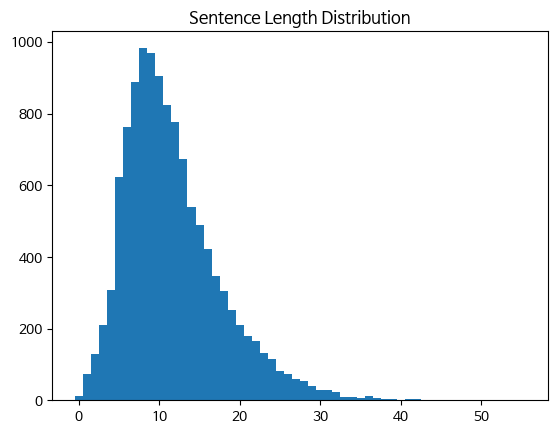

In [22]:
sentence_length = check_sentence_stats(preprocessed_df['Q'])

문장 길이 평균:  14.01838767344854
문장 길이 최대:  74
문장 길이 최소:  1
문장 길이 표준편차:  6.626894111821712
문장 길이 중위수:  13.0


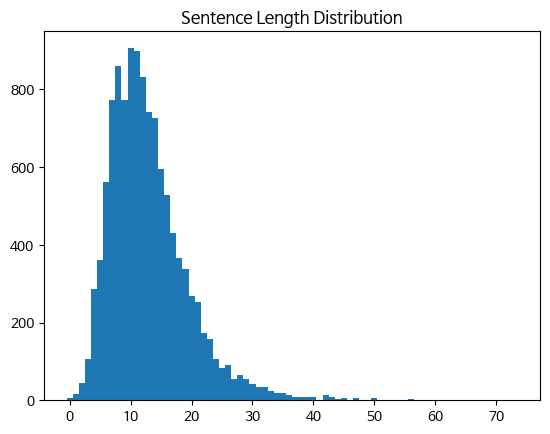

In [23]:
sentence_length = check_sentence_stats(preprocessed_df['A'])

&rarr; 평균이랑 중위수가 비슷한 위치에 있어서 치우치지 않은 좋은 분포임을 확인

## 1.2. data split

### 1.2.1. split 후 저장

In [22]:
# train:validation:test = 8:1:1 
train_df, tmp_eval_df = train_test_split(
    preprocessed_df, 
    test_size=0.2, 
    random_state=42, 
    shuffle=True
)

# validation
val_df, test_df = train_test_split(
    tmp_eval_df, 
    test_size=0.5, 
    random_state=42, 
    shuffle=True
)

# 인덱스 깔끔하게 초기화
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [25]:
# 결과 출력 확인
print("="*50)
print(f"(Train_df): {len(train_df)}개 (80%)")
print(f"(Val_df): {len(val_df)}개 (10%)")
print(f"(Test_df): {len(test_df)}개 (10%)")
print("-"*50)
print(f"총합: {len(train_df) + len(val_df) + len(test_df)}개")
print("="*50)

(Train_df): 9397개 (80%)
(Val_df): 1175개 (10%)
(Test_df): 1175개 (10%)
--------------------------------------------------
총합: 11747개


In [26]:
# 저장할 데이터들을 딕셔너리로 묶기
save_data = {
    'train': train_df, 'val': val_df, 'test': test_df
}

# 파일로 저장 (확장자는 보통 .pt 나 .pth 를 씁니다)
torch.save(save_data, os.path.join(DATA_DIR, 'split_data_origin.pt'))
print("split df 저장 완료!")

split df 저장 완료!


### 1.2.2. split data 불러와서 사용

In [24]:
# weights_only: 모델 가중치 텐서만 불러오겠다. (보안 문제로)
saved_split_data = torch.load(os.path.join(DATA_DIR, 'split_data_origin.pt'), weights_only=False)
saved_split_data.keys()

dict_keys(['train', 'val', 'test'])

In [25]:
train_df = saved_split_data['train']
val_df = saved_split_data['val']
test_df = saved_split_data['test']

print(len(train_df), len(val_df), len(test_df))

9397 1175 1175


### 1.2.3. data augmentation

In [24]:
import pickle

In [32]:
import os
import pickle
import numpy as np

pretrained_model_path = os.path.join(DATA_DIR, "ko_origin.bin")

print("ko.bin 파일 로우 레벨 바이트 해독 중...")
with open(pretrained_model_path, 'rb') as f:
    broken_model = pickle.load(f, encoding='latin1')

# 내부에 숨겨진 원본 단어 벡터 데이터 주소 탐색
if hasattr(broken_model, 'wv'):
    raw_wv = broken_model.wv
else:
    raw_wv = broken_model

# 단어장 리스트와 실수형 벡터 행렬 뜯어내기
if hasattr(raw_wv, 'index_to_key'):
    raw_words = raw_wv.index_to_key
    all_vectors = raw_wv.vectors
elif hasattr(raw_wv, 'vocab'):
    raw_words = list(raw_wv.vocab.keys())
    all_vectors = raw_wv.syn0 if hasattr(raw_wv, 'syn0') else raw_wv.vectors
else:
    raw_words = list(raw_wv.keys()) if hasattr(raw_wv, 'keys') else []
    all_vectors = raw_wv.vectors if hasattr(raw_wv, 'vectors') else np.array([])

# 💡 [핵심 세탁 작업] latin1으로 깨져서 들어온 단어들을 정상 UTF-8 한글로 인코딩->디코딩합니다.
print("깨진 인코딩 세탁 및 한글 복원 중...")
all_words = []
for word in raw_words:
    try:
        # latin1 문자를 바이트로 되돌린 후, 다시 utf-8로 온전하게 해석합니다.
        clean_word = word.encode('latin1').decode('utf-8')
        all_words.append(clean_word)
    except Exception:
        # 혹시나 변환이 안 되는 깨진 특수문자는 그대로 유지
        all_words.append(word)

print("초고속 연산을 위한 임베딩 행렬 정규화(L2 Normalization) 수행 중...")
norms = np.linalg.norm(all_vectors, axis=1, keepdims=True)
norms[norms == 0] = 1.0  # 0 나누기 방지
normalized_vectors = all_vectors / norms

# 검색 속도를 높이기 위한 단어 -> 행렬 인덱스 사전 구축
w2v_vocab = {word: i for i, word in enumerate(all_words)}

print(f"[준비 완료] 총 {len(all_words)}개의 단어 벡터가 복원되었습니다!")

# 🎯 [검증] 진짜 한글이 깨지지 않고 복원되었는지 상위 10개 출력
print("========================================")
print("샘플 단어 10개:", all_words[10:20]) # 앞의 공백/기호 피해서 10번부터 출력
print("========================================")

ko.bin 파일 로우 레벨 바이트 해독 중...
깨진 인코딩 세탁 및 한글 복원 중...
초고속 연산을 위한 임베딩 행렬 정규화(L2 Normalization) 수행 중...
[준비 완료] 총 30185개의 단어 벡터가 복원되었습니다!
샘플 단어 10개: ['광주시', '고민', '어로', '어록', '폴라리스', '십만', '관음', '효과적', '관의', '당뇨병']


In [33]:
from konlpy.tag import Mecab
import pandas as pd

mecab = Mecab()
# MAX_LENGTH = 20 # 노드에서 제시한 적정 길이로 맞추세요!

def build_corpus(df, tokenizer_func):
        
    que_corpus = []
    ans_corpus = []
    
    for _, row in df.iterrows():
        # 전처리 완료되었다고 가정된 텍스트 토큰화
        q_tokens = tokenizer_func(row['Q'])
        a_tokens = tokenizer_func(row['A'])        
        
        que_corpus.append(q_tokens)
        ans_corpus.append(a_tokens)
        
    return que_corpus, ans_corpus

# Step 3 실행 (que_corpus, ans_corpus는 이제 [['오늘', '날씨'], ...] 형태의 한글 토큰 리스트가 됨)
que_corpus, ans_corpus = build_corpus(train_df, mecab.morphs)
print(f"필터링 후 코퍼스 크기: {len(que_corpus)}")

필터링 후 코퍼스 크기: 9397


In [34]:
import random
import numpy as np

import re

def lexical_sub_perfect(tokens, w2v_vocab, normalized_vectors, all_words, sub_prob=0.15):
    augmented_tokens = []
    # 한글만 매칭하는 정규식 패턴 (영어, 특수문자, 외계어 차단)
    hangul_pattern = re.compile(r'^[가-힣]+$')
    
    for word in tokens:
        # 방어벽 1: 1글자짜리 조사/어미 차단
        if len(word) <= 1:
            augmented_tokens.append(word)
            continue
            
        if random.random() < sub_prob:
            if word in w2v_vocab:
                word_idx = w2v_vocab[word]
                target_vector = normalized_vectors[word_idx]
                
                similarities = np.dot(normalized_vectors, target_vector)
                similarities[word_idx] = -1.0
                
                # 유사도 상위 5개 중에서 한글인 단어가 나올 때까지 검사
                top_5_indices = np.argsort(similarities)[-5:][::-1]
                
                replaced = False
                for idx in top_5_indices:
                    sub_word = all_words[idx]
                    # 방어벽 2: 바뀔 단어가 2글자 이상이면서 오직 '순수 한글'일 때만 교체 허용!
                    if len(sub_word) > 1 and hangul_pattern.match(sub_word):
                        augmented_tokens.append(sub_word)
                        replaced = True
                        break
                
                if replaced:
                    continue
                    
        augmented_tokens.append(word)
    return augmented_tokens

# [3배 증강 파이프라인 실행]
final_que_corpus = []
final_ans_corpus = []

# 1. 원본 세트 그대로 추가 (1배)
final_que_corpus.extend(que_corpus)
final_ans_corpus.extend(ans_corpus)

# 2. Q만 증강 + A 원본 세트 추가 (2배)
for q_tokens, a_tokens in zip(que_corpus, ans_corpus):
    q_aug = lexical_sub_perfect(q_tokens, w2v_vocab, normalized_vectors, all_words)
    final_que_corpus.append(q_aug)
    final_ans_corpus.append(a_tokens)

# 3. Q 원본 + A만 증강 세트 추가 (3배)
for q_tokens, a_tokens in zip(que_corpus, ans_corpus):
    a_aug = lexical_sub_perfect(a_tokens, w2v_vocab, normalized_vectors, all_words)
    final_que_corpus.append(q_tokens)
    final_ans_corpus.append(a_aug)

print(f"3배 증강 후 최종 코퍼스 크기: {len(final_que_corpus)}")

3배 증강 후 최종 코퍼스 크기: 28191


In [35]:
# # 1. 가이드라인 조건: 타겟 데이터(ans_corpus) 앞뒤에 특수 토큰 추가
# v_ans_corpus = []
# for tokens in final_ans_corpus:
#     # list 형태이므로 아주 쉽게 부착 가능!
#     v_ans_corpus.append(['<start>'] + tokens + ['<end>'])

# # 2. 통합 어휘 사전(Vocab) 빌드 (증강된 단어와 특수 토큰 모두 포함)
# words_pool = set()
# for tokens in final_que_corpus:
#     words_pool.update(tokens)
# for tokens in v_ans_corpus:
#     words_pool.update(tokens)

# # 특수 토큰을 사전에 최우선 배치
# special_tokens = ['<pad>', '<unk>']
# word_to_index = {word: idx for idx, word in enumerate(special_tokens + list(words_pool))}
# index_to_word = {idx: word for word, idx in word_to_index.items()}

# # 3. 정수 인코딩 (숫자로 변환)
# unk_id = word_to_index['<unk>']

# enc_train_seq = [[word_to_index.get(w, unk_id) for w in tokens] for tokens in final_que_corpus]
# dec_train_seq = [[word_to_index.get(w, unk_id) for w in tokens] for tokens in v_ans_corpus]

# print(f"📐 사전에 등록된 총 단어 수: {len(word_to_index)}개")
# print("🚀 Step 5 완료! 모든 데이터가 교과서 순서대로 정수 인코딩되었습니다.")

In [36]:
# 💡 원본 코퍼스의 크기를 구합니다 (N)
N = len(que_corpus) 

print("=" * 60)
print("데이터 증강 전/후 1:1 리얼 비교")
print("=" * 60)

# 상위 3개 샘플만 딱 매칭해서 출력해봅니다.
for i in range(100, 105):
    print(f"[샘플 {i+1}]")
    
    # 1. 원본 세트 (0 ~ N-1 구간)
    print(f"  • 원본 질문  : {' '.join(final_que_corpus[i])}")
    print(f"  • 원본 답변  : {' '.join(final_ans_corpus[i])}")
    print(f"  " + "-"*40)
    
    # 2. Q만 증강된 세트 (i + N 구간)
    print(f"  • 🔁 Q 증강본 : {' '.join(final_que_corpus[i + N])}")
    print(f"  • 짝꿍 원본A : {' '.join(final_ans_corpus[i + N])}")
    print(f"  " + "-"*40)
    
    # 3. A만 증강된 세트 (i + 2N 구간)
    print(f"  • 짝꿍 원본Q : {' '.join(final_que_corpus[i + 2*N])}")
    print(f"  • 🔁 A 증강본 : {' '.join(final_ans_corpus[i + 2*N])}")
    
    print("=" * 60)

데이터 증강 전/후 1:1 리얼 비교
[샘플 101]
  • 원본 질문  : 다 잘 맞 는데 가치관 이 다른 연애 가 고민
  • 원본 답변  : 가치관 이 중요 한 거 같 아요
  ----------------------------------------
  • 🔁 Q 증강본 : 다 잘 맞 는데 가치관 이 살의 연애 가 고민
  • 짝꿍 원본A : 가치관 이 중요 한 거 같 아요
  ----------------------------------------
  • 짝꿍 원본Q : 다 잘 맞 는데 가치관 이 다른 연애 가 고민
  • 🔁 A 증강본 : 가치관 이 중요 한 거 같 아요
[샘플 102]
  • 원본 질문  : 연애 세포 가 다 죽 었 나
  • 원본 답변  : 그럴 수 있 어요 자연 스럽 게 대화 를 먼저 이어 나가 는 건 어떨까 요 ?
  ----------------------------------------
  • 🔁 Q 증강본 : 연애 세포 가 다 죽 었 나
  • 짝꿍 원본A : 그럴 수 있 어요 자연 스럽 게 대화 를 먼저 이어 나가 는 건 어떨까 요 ?
  ----------------------------------------
  • 짝꿍 원본Q : 연애 세포 가 다 죽 었 나
  • 🔁 A 증강본 : 그럴 수 있 거품 자연 무위 게 연차 를 먼저 이어 나가 는 건 어떨까 요 ?
[샘플 103]
  • 원본 질문  : 집착 같 은데 걔 는 뭐 라고 생각 할까
  • 원본 답변  : 상대 가 그렇게 느낀다면 요
  ----------------------------------------
  • 🔁 Q 증강본 : 집착 같 은데 걔 는 뭐 있다 만연 할까
  • 짝꿍 원본A : 상대 가 그렇게 느낀다면 요
  ----------------------------------------
  • 짝꿍 원본Q : 집착 같 은데 걔 는 뭐 라고 생각 할까
  • 🔁 A 증강본 : 상대 가 그렇게 느낀다면 요
[샘플 104]
  • 원본 질문  : 결정 

&rarr; 증강 자체가 잘 되지 않아서 쓰레기값이 들어갈 것으로 보임 ("증거 를" -> "스치 를")

In [98]:
final_que_corpus[0]

['이', '남자', '마음', '을', '모르', '겠', '어']

In [57]:
# 저장할 데이터들을 딕셔너리로 묶기
save_aug_data = {
    'train_q': final_que_corpus, 'train_a': final_ans_corpus
}

# 파일로 저장 (확장자는 보통 .pt 나 .pth 를 씁니다)
torch.save(save_aug_data, os.path.join(DATA_DIR, 'split_data_train_aug.pt'))
print("aug train corpus 저장 완료!")

aug train corpus 저장 완료!


- augmentation 데이터 불러와서 사용

In [26]:
saved_aug_train_data = torch.load(os.path.join(DATA_DIR, 'split_data_train_aug.pt'))
final_que_corpus, final_ans_corpus  = saved_aug_train_data['train_q'], saved_aug_train_data['train_a']
print(len(final_que_corpus), len(final_ans_corpus))

28191 28191


## 1.3. 토큰화

In [27]:
# Mecab 초기화
mecab = Mecab()

# 간단한 테스트
sample = "챗봇 데이터를 전처리하는 중입니다."
print(mecab.morphs(sample))
# 출력: ['챗봇', '데이터', '를', '전처리', '하', '는', '중', '입니다', '.']

['챗', '봇', '데이터', '를', '전처리', '하', '는', '중', '입니다', '.']


### 1.3.1. 토크나이징

- augmentation 미수행 시

In [28]:
# 모든 train 문장을 형태소 단위로 토큰화
tokenized_questions = [mecab.morphs(sentence) for sentence in train_df['Q']]
tokenized_answers = [mecab.morphs(sentence) for sentence in train_df['A']]

print("토큰화 예시(Q):", tokenized_questions[0])
print("토큰화 예시(A):", tokenized_answers[0])

토큰화 예시(Q): ['이', '남자', '마음', '을', '모르', '겠', '어']
토큰화 예시(A): ['알', '수', '없', '는', '게', '사람', '마음', '인가', '봐요']


- augmentation 수행 시

In [29]:
# augmentation 수행 시
tokenized_questions = final_que_corpus
tokenized_answers = final_ans_corpus

print("augmentation 토큰화 예시(Q):", final_que_corpus[0])
print("augmentation 토큰화 예시(A):", final_ans_corpus[0])

augmentation 토큰화 예시(Q): ['이', '남자', '마음', '을', '모르', '겠', '어']
augmentation 토큰화 예시(A): ['알', '수', '없', '는', '게', '사람', '마음', '인가', '봐요']


In [30]:
print(len(tokenized_questions), len(tokenized_answers))

28191 28191


In [31]:
# 모든 토큰을 하나의 리스트로 합치기
all_tokens = []
for tokens in tokenized_questions + tokenized_answers:
    all_tokens.extend(tokens)

# 빈도수 계산
token_counts = Counter(all_tokens)

# 특수 토큰(Special Tokens) 정의
# 패딩(PAD), 문장시작(BOS), 문장끝(EOS), 모르는단어(UNK)
SPECIAL_TOKENS = ['<pad>', '<unk>', '<bos>', '<eos>']
VOCAB_SIZE = 10000  # 원하는 사전 크기

# 빈도수 기준 상위 (VOCAB_SIZE - 특수토큰개수)만큼 단어 추출
common_words = [word for word, count in token_counts.most_common(VOCAB_SIZE - len(SPECIAL_TOKENS))]

# 최종 단어 사전 (단어 -> 정수 ID)
word_to_index = {word: index for index, word in enumerate(SPECIAL_TOKENS + common_words)}
# 반대 사전 (정수 ID -> 단어)
index_to_word = {index: word for word, index in word_to_index.items()}

print(f"실제 구축된 사전 크기: {len(word_to_index)}")

실제 구축된 사전 크기: 7502


In [32]:
VOCAB_SIZE = len(word_to_index)
VOCAB_SIZE

7502

- augmentation 수행 시

In [33]:
# 저장할 데이터들을 딕셔너리로 묶기
save_aug_vocab_data = {
    'word_to_index': word_to_index, 'index_to_word': index_to_word
}

# 파일로 저장 (확장자는 보통 .pt 나 .pth 를 씁니다)
torch.save(save_aug_vocab_data, os.path.join(DATA_DIR, 'save_aug_vocab_data.pt'))
print("save_aug_vocab_data 저장 완료!")

save_aug_vocab_data 저장 완료!


### 1.3.2. 정수 인코딩

- augmentation 미수행 시

In [39]:
def encode_sentences(raw_sentences, word_to_index):
    """텍스트 문장 리스트를 받아서 내부에서 Mecab 토큰화 후 정수 인코딩까지 한방에 처리"""
    mecab = Mecab()
    encoded_sentences = []
    
    unk_id = word_to_index['<unk>']
    bos_id = word_to_index['<bos>']  # BOS 토큰 ID
    eos_id = word_to_index['<eos>']  # EOS 토큰 ID
    
    for text in raw_sentences:
        # 💡 함수 안에서 Mecab으로 쪼개버리기!
        tokens = mecab.morphs(text)
        
        # 일반 형태소 단어들을 숫자로 변환
        encoded = [word_to_index.get(token, unk_id) for token in tokens]
        
        # 문장 앞뒤로 BOS와 EOS 부여        
        encoded_with_special = [bos_id] + encoded + [eos_id]
        
        encoded_sentences.append(encoded_with_special) 
        
    return encoded_sentences

- augmentation 수행 시 (train data)

In [40]:
def encode_tokens(tokenized_corpus, word_to_index):
    """
    이미 Mecab 토큰화 및 특수 토큰 처리가 완료된 코퍼스(리스트의 리스트)를 받아서
    순수하게 정수 인코딩(ID 변환)만 수행하는 함수
    """
    encoded_sentences = []
    unk_id = word_to_index['<unk>']
    bos_id = word_to_index['<bos>']  # BOS 토큰 ID
    eos_id = word_to_index['<eos>']  # EOS 토큰 ID
    
    for tokens in tokenized_corpus:
        # 이미 쪼개진 토큰 리스트를 순회하며 숫자로 변환
        encoded = [word_to_index.get(token, unk_id) for token in tokens]
        # 문장 앞뒤로 BOS와 EOS 부여        
        encoded_with_special = [bos_id] + encoded + [eos_id]

        encoded_sentences.append(encoded_with_special)
        
    return encoded_sentences

In [41]:
enc_train_seq_aug = encode_tokens(tokenized_questions, word_to_index)
dec_train_seq_aug = encode_tokens(tokenized_answers, word_to_index)

In [42]:
# Train 데이터셋 인코딩
# enc_train_seq = encode_sentences(train_df['Q'], word_to_index)
# dec_train_seq = encode_sentences(train_df['A'], word_to_index)

# Validation 데이터셋 인코딩
enc_val_seq = encode_sentences(val_df['Q'], word_to_index)
dec_val_seq = encode_sentences(val_df['A'], word_to_index)

# Test 데이터셋 인코딩
enc_test_seq = encode_sentences(test_df['Q'], word_to_index)
dec_test_seq = encode_sentences(test_df['A'], word_to_index)

In [43]:
# augmentation 수행 시
enc_train_seq = enc_train_seq_aug
dec_train_seq = dec_train_seq_aug

In [44]:
print("정수 변환 예시(Q):", enc_train_seq[0])
print("정수 변환 예시(A):", dec_train_seq[0])

print("정수 변환 예시(Q):", enc_val_seq[0])
print("정수 변환 예시(A):", dec_val_seq[0])

print("정수 변환 예시(Q):", enc_test_seq[0])
print("정수 변환 예시(A):", dec_test_seq[0])

정수 변환 예시(Q): [2, 4, 68, 55, 7, 122, 24, 10, 3]
정수 변환 예시(A): [2, 93, 40, 41, 6, 23, 27, 55, 156, 46, 3]
정수 변환 예시(Q): [2, 75, 127, 6, 27, 99, 60, 95, 59, 51, 94, 290, 10, 19, 3]
정수 변환 예시(A): [2, 805, 42, 4, 218, 110, 4, 12, 20, 5, 11, 1127, 6, 466, 4, 12, 47, 3]
정수 변환 예시(Q): [2, 1225, 1, 32, 75, 284, 124, 5303, 19, 3]
정수 변환 예시(A): [2, 339, 96, 79, 3630, 16, 9, 3]


### 1.3.3. 패딩 처리

In [45]:
# Train, Val, Test의 인코딩된 시퀀스를 모두 합쳐서 길이 리스트 생성
all_q_lens = [len(q) for q in enc_train_seq] + [len(q) for q in enc_val_seq] + [len(q) for q in enc_test_seq]
all_a_lens = [len(a) for a in dec_train_seq] + [len(a) for a in dec_val_seq] + [len(a) for a in dec_test_seq]

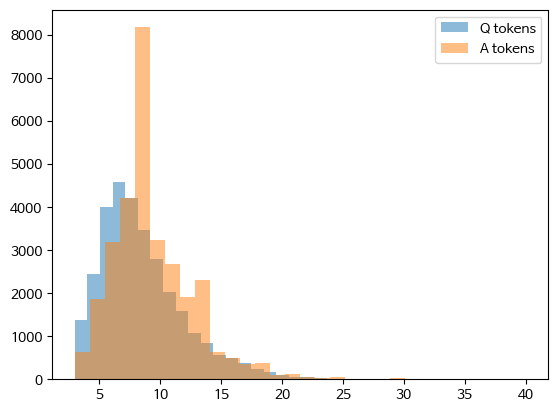

Q 토큰 최대: 34
A 토큰 최대: 40


In [46]:
# 전체 데이터 길이 분포 확인
plt.hist(all_q_lens, bins=30, alpha=0.5, label='Q tokens')
plt.hist(all_a_lens, bins=30, alpha=0.5, label='A tokens')
plt.legend()
plt.show()

print(f"Q 토큰 최대: {max(all_q_lens)}")
print(f"A 토큰 최대: {max(all_a_lens)}")

In [47]:
# BOS, EOS 토큰 고려하면 최소 42이상 지정 필요
# inference 단계에서 더 긴 글이 들어올 수 있으므로 50으로 지정하고
# 인코더, 디코더 공용으로 사용

MAX_LEN = 50
pad_val = word_to_index['<pad>']
pad_val

0

In [48]:
def pad_sequences_custom(sequences, max_len=50, pad_value=0):
    """
    sequences: list of list (각 문장별 토큰 id 리스트)
    max_len: 고정할 최대 시퀀스 길이
    pad_value: 패딩에 사용할 값 (일반적으로 0)
    """

    padded_sequences = []

    for seq in sequences:
        # 초과 길이는 자르고
        if len(seq) > max_len:
            seq = seq[:max_len]
        # 부족한 길이는 pad_value로 채우기
        else:
            seq = seq + [pad_value]*(max_len - len(seq))
        
        padded_sequences.append(seq)

    # 최종적으로 torch.tensor로 변환 (shape: [batch_size, max_len])

    return torch.tensor(padded_sequences, dtype=torch.long)

In [49]:
enc_tensor_train = pad_sequences_custom(enc_train_seq, max_len=MAX_LEN, pad_value=pad_val)
dec_tensor_train = pad_sequences_custom(dec_train_seq, max_len=MAX_LEN, pad_value=pad_val)

enc_tensor_val = pad_sequences_custom(enc_val_seq, max_len=MAX_LEN, pad_value=pad_val)
dec_tensor_val = pad_sequences_custom(dec_val_seq, max_len=MAX_LEN, pad_value=pad_val)

enc_tensor_test = pad_sequences_custom(enc_test_seq, max_len=MAX_LEN, pad_value=pad_val)
dec_tensor_test = pad_sequences_custom(dec_test_seq, max_len=MAX_LEN, pad_value=pad_val)

print(enc_tensor_train.shape, enc_tensor_val.shape, enc_tensor_test.shape)
print(dec_tensor_train.shape, dec_tensor_val.shape, dec_tensor_test.shape)

torch.Size([28191, 50]) torch.Size([1175, 50]) torch.Size([1175, 50])
torch.Size([28191, 50]) torch.Size([1175, 50]) torch.Size([1175, 50])


## 1.4. Dataset, DataLoader 생성

In [50]:
BATCH_SIZE = 64


train_dataset = TensorDataset(enc_tensor_train, dec_tensor_train)
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)

val_dataset = TensorDataset(enc_tensor_val, dec_tensor_val)
val_loader = DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

test_dataset = TensorDataset(enc_tensor_test, dec_tensor_test)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

In [43]:
# augmentation 기반 인코딩된 test 인코딩 토큰 저장
save_encoded_test_origin = {
    'origin_test_q': enc_tensor_test, 'origin_test_a': dec_tensor_test
}

# 파일로 저장 (확장자는 보통 .pt 나 .pth 를 씁니다)
torch.save(save_encoded_test_origin, os.path.join(DATA_DIR, 'encoded_test_origin.pt'))
print("encoded_test_origin 저장 완료!")

encoded_test_origin 저장 완료!


In [ ]:
# augmentation 기반 인코딩된 test 인코딩 토큰 저장
save_encoded_test_aug = {
    'train_q': enc_tensor_test, 'train_a': dec_tensor_test
}

# 파일로 저장 (확장자는 보통 .pt 나 .pth 를 씁니다)
torch.save(save_encoded_test_aug, os.path.join(DATA_DIR, 'encoded_test_aug.pt'))
print("encoded_test_aug 저장 완료!")

encoded_test_aug 저장 완료!


# 2. 모델 정의

In [66]:
# Positional Encoding
def pos_encoding(pos, emb_dim):
    def cal_angle(pos, i):
        return pos / np.power(10000, (2*(i//2)) / np.float32(emb_dim))
    
    def get_pos_angle_vec(pos):
        return [cal_angle(pos, i) for i in range(emb_dim)] 
    
    sinusoid_table = np.array([get_pos_angle_vec(pos_i) for pos_i in range(pos)])

    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2]) # 짝수는 sin
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2]) # 홀수는 cos

    return sinusoid_table   

In [67]:
def generate_pad_mask(seq: torch.Tensor) -> torch.Tensor:
    """
    seq: shape [batch_size, seq_len]의 입력 (토큰 id 텐서)
    반환: shape [batch_size, 1, 1, seq_len]의 패딩 마스크
        (seq == 0)인 위치가 1, 나머지는 0
    """

    # (seq == 0)은 불리언 텐서를 반환 -> float()로 형변환 -> (1.0 or 0.0)
    # 차원 확장: [batch_size, seq_len] -> [batch_size, 1, 1, seq_len]

    return (seq==0).unsqueeze(1).unsqueeze(2).float()

In [68]:
def generate_lookahead_mask(seq_len: int) -> torch.Tensor:
    """ 
    seq_len: 문장(시퀀스) 길이
    반환: shape [seq_len, seq_len], i<j (대각선 위)에 해당하는 위치가 1, 아닌 곳은 0
        (미래 토큰을 가리기 위한 마스크) -> 1인 곳만 -inf 만들어서 softmax 결과 0으로
    """

    # triu(diagonal=1)은 주대각선 위가 1, 아래가 0인 텐서를 만들어 줌
    return torch.triu(torch.ones(seq_len, seq_len), diagonal=1)

In [69]:
def generate_masks(src: torch.Tensor, tgt: torch.Tensor):
    """
    src, tgt: shape [batch_size, seq_len]
    3가지 마스크를 반환:
      - enc_mask: 인코더 입력용 패딩 마스크
      - dec_enc_mask: 디코더-인코더 어텐션용 패딩 마스크
      - dec_mask: 디코더 self 어텐션용 마스크(룩어헤드 + 패딩)

    각각의 shape:
      - enc_mask, dec_enc_mask: [batch_size, 1, 1, src_seq_len]
      - dec_mask: [batch_size, 1, tgt_seq_len, tgt_seq_len]
    """

    # 1) 인코더 입력용 패딩 마스크
    enc_mask = generate_pad_mask(src)
    # 2) 디코더에서 인코더 값을 볼 때 사용하는 마스크 (src 마스크 재사용)
    dec_enc_mask = generate_pad_mask(src)

    # 디코더 셀프 어텐션 마스크 (미래 토큰 방지 + tgt 패딩)
    dec_lookahead_mask = generate_lookahead_mask(tgt.shape[1]) # [tgt_seq_len, tgt_seq_len]
    dec_tgt_pad_mask = generate_pad_mask(tgt) # [batch_size, 1, 1, tgt_seq_len]

    # 룩어헤드 마스크를 (batch 차원과 head 차원을 가상으로) 확장
    dec_lookahead_mask = dec_lookahead_mask.unsqueeze(0).unsqueeze(1) # [1, 1, tgt_seq_len, tgt_seq_len]

    # 패딩 + 룩어헤드 마스크 병합
    # 브로드캐스팅에 의해 shape [batch_size, 1, tgt_seq_len, tgt_seq_len]이 됨
    dec_tgt_pad_mask = dec_tgt_pad_mask.to(DEVICE)
    dec_lookahead_mask = dec_lookahead_mask.to(DEVICE)

    # 브로드 캐스팅하면서 or 연산처럼 pad, lookahead 하나라도 해당돼서 1 있는 자리 1로 채움
    dec_mask = torch.max(dec_tgt_pad_mask, dec_lookahead_mask) 

    return enc_mask, dec_enc_mask, dec_mask

In [70]:
class MHA(nn.Module):
    def __init__(self, emb_dim, n_heads):
        super().__init__()
        self.emb_dim = emb_dim
        self.n_heads = n_heads

        # 각 헤드의 차원 수: emb_dim을 n_heads로 나눈 값
        self.h_dim = emb_dim // self.n_heads

        # Q, K, V 구하는 Linear
        self.wq = nn.Linear(emb_dim, emb_dim)
        self.wk = nn.Linear(emb_dim, emb_dim)
        self.wv = nn.Linear(emb_dim, emb_dim)

        # 최종적으로 헤드들의 결과를 결합하는 linear
        self.combine_linear = nn.Linear(emb_dim, emb_dim)

    def scaled_dot_product_attn(self, Q, K, V, mask=None):
        """
        Q, K, V:  [batch_size, num_heads, seq_len, depth]
        mask:     [batch_size, 1, seq_len, seq_len] 혹은
                  [batch_size, num_heads, seq_len, seq_len]
                  (어텐션에서 제외할 위치=1, 사용할 위치=0)
        """

        d_k = Q.size(-1) # h_dim        
        QK = torch.matmul(Q, K.transpose(-1, -2))

        # 스케일링
        scaled_QK = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        # 마스크가 있는 경우 -1e9(매우 작은 음수)를 더하여 softmax 후 확률이 0에 가깝도록 처리
        if mask is not None:
            scaled_QK = scaled_QK + (mask * -1e9)

        attn_weights = F.softmax(scaled_QK, dim=-1) # (batch_size, num_heads, seq_len, seq_len)
        attn_values = torch.matmul(attn_weights, V) # # (batch_size, num_heads, seq_len, h_dim)

        return attn_values, attn_weights
    
    def split_heads(self, x):
        """
        x: [batch_size, seq_len, emb_dim]
        반환: [batch_size, num_heads, seq_len, h_dim]        
        """

        # [batch_size, seq_len, n_heads, h_dim]으로 먼저 쪼갬
        batch_size, seq_len, _ = x.shape
        # emb_dim -> (n_heads * h_dim)이므로 view로 재배치
        x = x.view(batch_size, seq_len, self.n_heads, self.h_dim)

        # (batch_size, seq_len, n_heads, h_dim) -> (batch_size, n_heads, seq_len, h_dim)
        x = x.permute(0, 2, 1, 3)
        
        return x
    
    def combine_heads(self, x):
        """
        x: [batch_size, num_heads, seq_len, h_dim]
        qksghks: [batch_size, seq_len, emb_dim]
        """
        batch_size, n_heads, seq_len, h_dim = x.size()
        # (batch_size, n_heads, seq_len, h_dim) -> (batch_size, seq_len, n_heads, h_dim)
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(batch_size, seq_len, self.emb_dim)
        
        return x
    
    def forward(self, Q, K, V, mask=None):
        """
        Q, K, V: [batch_size, seq_len, d_model]
        mask:    [batch_size, 1, seq_len, seq_len] 혹은
                 [batch_size, num_heads, seq_len, seq_len]
        """
        # wq, wk, wv는 각각 (emb_dim -> emb_dim) 선형 변환
        Q = self.wq(Q) # [batch_size, seq_len, emb_dim]
        K = self.wk(K) # [batch_size, seq_len, emb_dim]
        V = self.wv(V) # [batch_size, seq_len, emb_dim]

        # 멀티 헤드 분할
        Q_split = self.split_heads(Q) # [batch_size, num_heads, seq_len, depth]
        K_split = self.split_heads(K)
        V_split = self.split_heads(V)

        # Scaled dot-product attention
        attn_values, attn_weights = self.scaled_dot_product_attn(Q_split, K_split, V_split, mask)

        # head 결과 결합 후 최종 선형 연산
        out = self.combine_heads(attn_values) # [batch_size, seq_len, emb_dim]
        out = self.combine_linear(out) # [batch_size, seq_len, emb_dim]

        return out, attn_weights

In [71]:
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, emb_dim, ff_dim):
        super().__init__()

        self.emb_dim = emb_dim
        self.ff_dim = ff_dim

        self.fc1 = nn.Linear(emb_dim, ff_dim)
        self.fc2 = nn.Linear(ff_dim, emb_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.fc1(x)) # 
        out = self.fc2(out)
        return out

In [72]:
class EncoderBlock(nn.Module):
    def __init__(self, emb_dim, n_heads, ff_dim, dropout):
        super().__init__()

        self.enc_self_attn = MHA(emb_dim, n_heads)
        self.ffn = PoswiseFeedForwardNet(emb_dim, ff_dim)

        # nn.LayerNorm은 마지막 차원(emb_dim) 기준으로 정규화
        self.norm1 = nn.LayerNorm(emb_dim, eps=1e-6)
        self.norm2 = nn.LayerNorm(emb_dim, eps=1e-6)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        # MHA
        residual = x
        out = self.norm1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.dropout(out)
        out = out + residual # residual connection

        # posional-wise ff
        residual = out
        out = self.ffn(out)
        out = self.dropout(out)
        out = out + residual

        return out, enc_attn

In [73]:
class DecoderBlock(nn.Module):
    def __init__(self, emb_dim, n_heads, ff_dim, dropout):
        super().__init__()

        self.dec_self_attn = MHA(emb_dim, n_heads)
        self.enc_dec_attn = MHA(emb_dim, n_heads)
        self.ffn = PoswiseFeedForwardNet(emb_dim, ff_dim)

        self.norm1 = nn.LayerNorm(emb_dim, eps=1e-6)
        self.norm2 = nn.LayerNorm(emb_dim, eps=1e-6)
        self.norm3 = nn.LayerNorm(emb_dim, eps=1e-6)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, enc_dec_mask, pad_mask):
        # MHA
        residual = x
        out = self.norm1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, mask=pad_mask)
        out = self.dropout(out)
        out = out + residual

        # Encoder-Decoder Multi-Head Attention (주의: Q, K, V 순서)
        residual = out
        out = self.norm2(out)
        out, enc_dec_attn = self.enc_dec_attn(out, enc_out, enc_out, mask=enc_dec_mask)
        out = self.dropout(out)
        out = out + residual

        # ff
        residual = out
        out = self.norm3(out)
        out = self.ffn(out)
        out = self.dropout(out)
        out += residual

        return out, dec_attn, enc_dec_attn

In [74]:
class Encoder(nn.Module):
    def __init__(self, n_layers, emb_dim, n_heads, ff_dim, dropout):
        super().__init__()
        self.n_layers = n_layers
        self.enc_layers = nn.ModuleList([
            EncoderBlock(emb_dim, n_heads, ff_dim, dropout) for _ in range(n_layers)
        ])
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        out = x
        enc_attns = []
        for i in range(self.n_layers):
            out, enc_attn = self.enc_layers[i](out, mask)
            enc_attns.append(enc_attn)
        return out, enc_attns

In [75]:
class Decoder(nn.Module):
    def __init__(self, n_layers, emb_dim, n_heads, ff_dim, dropout):
        super().__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList([
            DecoderBlock(emb_dim, n_heads, ff_dim, dropout) for _ in range(n_layers)
        ])

    def forward(self, x, enc_out, enc_dec_mask, pad_mask):
        out = x
        dec_attns = []
        enc_dec_attns = []
        for i in range(self.n_layers):
            out, dec_attn, enc_dec_attn = self.dec_layers[i](out, enc_out, enc_dec_mask, pad_mask)
            dec_attns.append(dec_attn)
            enc_dec_attns.append(enc_dec_attn)
        return out, dec_attns, enc_dec_attns

In [76]:
class Transformer(nn.Module):
    def __init__(self, n_layers, emb_dim, n_heads, ff_dim,
                 src_vocab_size, tgt_vocab_size, pos_len, dropout=0.2, shared_fc=True, shared_emb=False):
        super().__init__()
        # emb_dim은 스케일링에 사용되므로 float으로 저장
        self.emb_dim = float(emb_dim)

        # Embedding 레이어: shared_emb True면 동일한 임베딩을 사용합니다.
        if shared_emb:
            self.enc_embedding = nn.Embedding(src_vocab_size, emb_dim)
            self.dec_embedding = self.enc_embedding
        else:
            self.enc_embedding = nn.Embedding(src_vocab_size, emb_dim)
            self.dec_embedding = nn.Embedding(tgt_vocab_size, emb_dim)

        # Positional encoding (넘파이 버전 결과를 torch.Tensor로 변환)
        pos_encoding_np = pos_encoding(pos_len, emb_dim)
        # 파라미터로 등록하지 않고 고정값이므로 buffer로 등록합니다.
        # 학습(Update)은 안 하지만, 모델이 GPU로 이동할 때나 파일로 저장될 때 꼭 세트로 같이 움직여야 하는 고정 데이터
        self.register_buffer("pos_encoding", torch.tensor(pos_encoding_np, dtype=torch.float32))

        self.dropout = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, emb_dim, n_heads, ff_dim, dropout)
        self.decoder = Decoder(n_layers, emb_dim, n_heads, ff_dim, dropout)

        self.fc = nn.Linear(emb_dim, tgt_vocab_size)

        self.shared_fc = shared_fc
        if shared_fc:
            # fc 레이어와 디코더 임베딩의 weight를 공유합니다.
            self.fc.weight = self.dec_embedding.weight

    def embedding(self, emb, x):
        """
        emb: 임베딩 레이어
        x: [batch_size, seq_len] (토큰 인덱스)
        """

        seq_len = x.size(1)
        out = emb(x) # [batch_size, seq_len, emb_dim]
        if self.shared_fc:
            out = out * math.sqrt(self.emb_dim)
        
        # pos_encoding: [pos_len, d_model] → [1, pos_len, d_model] 후 슬라이싱
        out = out + self.pos_encoding[:seq_len, :].unsqueeze(0)
        out = self.dropout(out)
        return out

    def forward(self, enc_in, dec_in, enc_mask, enc_dec_mask, dec_mask):
        """
        enc_in: [batch_size, src_seq_len]
        dec_in: [batch_size, tgt_seq_len]
        enc_mask, dec_enc_mask, dec_mask: 마스킹 텐서들
        """

        # Embedding 및 positional encoding 적용
        enc_in_emb = self.embedding(self.enc_embedding, enc_in)
        dec_in_emb = self.embedding(self.dec_embedding, dec_in)

        # encoder, decoder 통과
        enc_out, enc_attns = self.encoder(enc_in_emb, enc_mask)
        dec_out, dec_attns, enc_dec_attns = self.decoder(dec_in_emb, enc_out, enc_dec_mask, dec_mask)

        logits = self.fc(dec_out)
        return logits, enc_attns, dec_attns, enc_dec_attns
    


In [71]:
# # 주어진 하이퍼파라미터로 Transformer 인스턴스 생성
# transformer = Transformer(
#     n_layers=2,
#     emb_dim=512,
#     n_heads=8,
#     ff_dim=2048,
#     src_vocab_size=VOCAB_SIZE,
#     tgt_vocab_size=VOCAB_SIZE,
#     pos_len=200,
#     dropout=0.3,
#     shared_fc=True,
#     shared_emb=True)

# transformer = transformer.to(DEVICE)

# emb_dim = 512

In [78]:
N_LAYERS=2
EMB_DIM=128
N_HEADS=4
FF_DIM=1024

In [56]:
# 주어진 하이퍼파라미터로 Transformer 인스턴스 생성
transformer = Transformer(
    n_layers=N_LAYERS,
    emb_dim=EMB_DIM,
    n_heads=N_HEADS,
    ff_dim=FF_DIM,
    src_vocab_size=VOCAB_SIZE,
    tgt_vocab_size=VOCAB_SIZE,
    pos_len=200,
    dropout=0.1,
    shared_fc=True,
    shared_emb=True)

transformer = transformer.to(DEVICE)

emb_dim = EMB_DIM

# 3. 모델 학습

In [57]:
class LearningRateScheduler:
    def __init__(self, emb_dim, warmup_steps=60): # 4000
        self.emb_dim = emb_dim
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        # step을 float으로 변환하여 지수 연산이 제대로 수행되도록 함
        step = float(step)
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        return (self.emb_dim ** -0.5) * min(arg1, arg2)

In [58]:
# Learning Rate 인스턴스 선언
learning_rate = LearningRateScheduler(emb_dim)

# 초기 lr은 스텝 1에 해당하는 값으로 설정합니다.
optimizer = torch.optim.Adam(transformer.parameters(),
                             lr=learning_rate(1),
                             betas=(0.9, 0.98),
                             eps=1e-9)

In [59]:
def loss_function(gt, pred):
    """
    gt: [batch_size, seq_len] (정답 토큰 인덱스)
    pred: [batch_size, seq_len, num_classes] (모델의 raw logits)
    """

    gt = gt.to(DEVICE)
    pred = pred.to(DEVICE)

    # 예측 값을 (N, C) 형태로 flatten하고, 정답도 flatten하여 개별 손실 값을 구함
    # 기본값은 모든 문장의 점수를 평균 낸 '단 하나의 숫자'를 반환하지만, 
    # reduction='none'으로 설정하면 문장 속 모든 단어 하나하나가 각각 몇 점 짜리 손실을 냈는지 전부 따로 리스트로 반환
    # 이후 패딩 토큰 골라내야 해서
    loss_ = F.cross_entropy(pred.contiguous().view(-1, pred.size(-1)), gt.contiguous().view(-1), reduction='none')
    # 다시 (batch_size, seq_len)로 reshape
    loss_ = loss_.view(gt.size())

    # gt이 0이 아닌 위치에 대한 마스크 생성 (0이면 패딩 토큰)
    mask = (gt != 0).float()
    loss_ = loss_ * mask

    # 전체 손실 합을 마스크 합으로 나누어 평균 손실 계산
    return loss_.sum() / mask.sum()


In [60]:
def loss_function(real, pred):
    # pred shape: [batch_size, seq_len, num_classes] -> [N, C] 형태로 변경
    # real shape: [batch_size, seq_len] -> [N] 형태로 변경
    # ignore_index=0 을 주면 패딩(0번)은 알아서 분자, 분모에서 완전히 제외하고 순수 평균을 냅니다.
    
    return F.cross_entropy(
        pred.contiguous().view(-1, pred.size(-1)), 
        real.contiguous().view(-1), 
        ignore_index=0  # ⭐ 이 한 줄이 위의 mask 연산 전체를 대체합니다.
    )

In [61]:
def train_step(src, tgt, model, optimizer):
    model.train()  # 모델을 training 모드로 전환
    optimizer.zero_grad()

    # tgt의 오른쪽 시프트: decoder input과 gold target 분리
    tgt_in = tgt[:, :-1]  # Decoder의 입력
    gt = tgt[:, 1:]     # Decoder의 정답(target)

    # 마스크 생성 (generate_masks는 PyTorch용으로 변환된 함수여야 합니다)
    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)

    src = src.to(DEVICE)
    tgt_in = tgt_in.to(DEVICE)
    enc_mask = enc_mask.to(DEVICE)
    dec_enc_mask = dec_enc_mask.to(DEVICE)
    dec_mask = dec_mask.to(DEVICE)

    # 모델 forward pass
    predictions, enc_attns, dec_attns, dec_enc_attns = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)

    # loss 계산
    loss = loss_function(gt, predictions)

    # 역전파 수행 및 파라미터 업데이트
    loss.backward()
    optimizer.step()

    return loss, enc_attns, dec_attns, dec_enc_attns


In [62]:
def train_step(src, tgt, model, optimizer):
    model.train()
    optimizer.zero_grad()

    # tgt의 오른쪽 시프트: decoder input과 gold target 분리
    tgt_in = tgt[:, :-1]  
    gt = tgt[:, 1:]     

    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)

    src, tgt_in = src.to(DEVICE), tgt_in.to(DEVICE)
    gt = gt.to(DEVICE)
    enc_mask, dec_enc_mask, dec_mask = enc_mask.to(DEVICE), dec_enc_mask.to(DEVICE), dec_mask.to(DEVICE)

    predictions, enc_attns, dec_attns, dec_enc_attns = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)

    # 1. Loss 계산
    loss = loss_function(gt, predictions)

    # 2. 역전파 및 업데이트
    loss.backward()
    optimizer.step()

    # 3. Accuracy 계산을 위한 배치별 통계 추출
    # predictions shape: [batch_size, seq_len, vocab_size] -> 가장 확률 높은 단어 ID 추출
    pred_tokens = predictions.argmax(dim=-1) 
    
    # 패딩(0번이라고 가정)은 맞춘 개수 계산에서 제외하기 위한 마스크
    non_pad_mask = (gt != 0) 
    
    # 패딩이 아닌 것 중 정답과 일치하는 개수와 총 패딩 아닌 단어 수 계산
    correct = ((pred_tokens == gt) & non_pad_mask).sum().item()
    total_tokens = non_pad_mask.sum().item()

    # 나중에 러닝 커브를 위해 맞춘 정보(correct, total_tokens)를 함께 넘겨줍니다.
    return loss.item(), correct, total_tokens

def val_step(src, tgt, model):
    model.eval()  # Evaluation 모드 전환 (Dropout 비활성화)
    
    tgt_in = tgt[:, :-1]  
    gt = tgt[:, 1:]     

    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)

    src, tgt_in = src.to(DEVICE), tgt_in.to(DEVICE)
    gt = gt.to(DEVICE)
    enc_mask, dec_enc_mask, dec_mask = enc_mask.to(DEVICE), dec_enc_mask.to(DEVICE), dec_mask.to(DEVICE)

    with torch.no_grad():
        predictions, _, _, _ = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)
        loss = loss_function(gt, predictions)

    pred_tokens = predictions.argmax(dim=-1) 
    non_pad_mask = (gt != 0) 
    correct = ((pred_tokens == gt) & non_pad_mask).sum().item()
    total_tokens = non_pad_mask.sum().item()

    return loss.item(), correct, total_tokens

In [63]:

# history = {
#     'train_loss': [], 'val_loss': [],
#     'train_acc': [], 'val_acc': []
# }

# EPOCHS = 150

# for epoch in range(EPOCHS):
#     # --- [1] TRAIN PHASE ---
#     total_train_loss = 0.0
#     total_train_correct = 0
#     total_train_tokens = 0
    
#     train_dataset_count = len(train_loader)
#     # tqdm 뒤에 desc를 붙여서 현재 에폭을 표시해 주면 더 보기 좋습니다.
#     tqdm_bar = tqdm(total=train_dataset_count, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")

#     for batch, (src, tgt) in enumerate(train_loader):
#         # 💡 앞서 수정한 train_step은 (loss_val, correct, tokens)를 반환합니다.
#         loss_val, correct, tokens = train_step(src, tgt, transformer, optimizer)

#         total_train_loss += loss_val
#         total_train_correct += correct
#         total_train_tokens += tokens
        
#         # 실시간으로 배치당 Loss와 정확도를 프로그레스 바에 표시
#         current_acc = correct / tokens if tokens > 0 else 0
#         tqdm_bar.set_postfix({
#             "Loss": f"{loss_val:.4f}", 
#             "Acc": f"{current_acc:.4f}"
#         })
#         tqdm_bar.update(1)

#     tqdm_bar.close()
    
#     # 에폭 최종 Train 결과 계산
#     epoch_train_loss = total_train_loss / train_dataset_count
#     epoch_train_acc = total_train_correct / total_train_tokens

#     # --- [2] VALIDATION PHASE ---
#     total_val_loss = 0.0
#     total_val_correct = 0
#     total_val_tokens = 0
    
#     val_dataset_count = len(val_loader)
    
#     # 검증할 때는 가중치 업데이트가 없으니 tqdm 없이 빠르게 돌리거나 
#     # 원하시면 가볍게 통계만 취합합니다. (여기서는 안전하게 루프로 취합)
#     for src, tgt in val_loader:
#         loss_val, correct, tokens = val_step(src, tgt, transformer)
#         total_val_loss += loss_val
#         total_val_correct += correct
#         total_val_tokens += tokens
        
#     epoch_val_loss = total_val_loss / val_dataset_count
#     epoch_val_acc = total_val_correct / total_val_tokens

#     # 💾 3. 최종 메트릭을 history에 영구 저장 (러닝 커브용)
#     history['train_loss'].append(epoch_train_loss)
#     history['train_acc'].append(epoch_train_acc)
#     history['val_loss'].append(epoch_val_loss)
#     history['val_acc'].append(epoch_val_acc)

#     # 에폭 결과 깔끔하게 프린트
#     print(f"==> Epoch {epoch+1} 완료")
#     print(f"    [Train] Loss: {epoch_train_loss:.4f} | Acc: {epoch_train_acc:.4f}")
#     print(f"    [Val]   Loss: {epoch_val_loss:.4f} | Acc: {epoch_val_acc:.4f}\n")

In [64]:
import numpy as np

# 📈 러닝 커브 시각화를 위한 기록 딕셔너리
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

EPOCHS = 300

# 🛡️ Early Stopping & 저장 관련 하이퍼파라미터 세팅
best_val_loss = float('inf')  # 가장 낮은 검증 손실을 기록하기 위한 변수 (초기값은 무한대)
patience = 10                  # 검증 손실이 개선되지 않을 때 몇 에폭까지 참을 것인가
patience_counter = 0           # 연속으로 개선되지 않은 에폭 수를 세는 카운터
# model_name = f"best_model-layers-{N_LAYERS}-emb-{EMB_DIM}-HEADS-{N_HEADS}-FF-{FF_DIM}_origin.pt"  # 베스트 모델 가중치를 저장할 파일명
model_name = f"best_model-layers-{N_LAYERS}-emb-{EMB_DIM}-HEADS-{N_HEADS}-FF-{FF_DIM}_aug.pt"  # 베스트 모델 가중치를 저장할 파일명
model_path = os.path.join(MODEL_DIR, model_name)

for epoch in range(EPOCHS):
    # --- [1] TRAIN PHASE ---
    total_train_loss = 0.0
    total_train_correct = 0
    total_train_tokens = 0
    
    train_dataset_count = len(train_loader)
    tqdm_bar = tqdm(total=train_dataset_count, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")

    for batch, (src, tgt) in enumerate(train_loader):
        loss_val, correct, tokens = train_step(src, tgt, transformer, optimizer)

        total_train_loss += loss_val
        total_train_correct += correct
        total_train_tokens += tokens
        
        current_acc = correct / tokens if tokens > 0 else 0
        tqdm_bar.set_postfix({
            "Loss": f"{loss_val:.4f}", 
            "Acc": f"{current_acc:.4f}"
        })
        tqdm_bar.update(1)

    tqdm_bar.close()
    
    epoch_train_loss = total_train_loss / train_dataset_count
    epoch_train_acc = total_train_correct / total_train_tokens

    # --- [2] VALIDATION PHASE ---
    total_val_loss = 0.0
    total_val_correct = 0
    total_val_tokens = 0
    
    val_dataset_count = len(val_loader)
    
    for src, tgt in val_loader:
        loss_val, correct, tokens = val_step(src, tgt, transformer)
        total_val_loss += loss_val
        total_val_correct += correct
        total_val_tokens += tokens
        
    epoch_val_loss = total_val_loss / val_dataset_count
    epoch_val_acc = total_val_correct / total_val_tokens

    # 💾 3. 최종 메트릭을 history에 영구 저장 (러닝 커브용)
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)

    # 에폭 결과 깔끔하게 프린트
    print(f"==> Epoch {epoch+1} 완료")
    print(f"    [Train] Loss: {epoch_train_loss:.4f} | Acc: {epoch_train_acc:.4f}")
    print(f"    [Val]   Loss: {epoch_val_loss:.4f} | Acc: {epoch_val_acc:.4f}")

    # --- 🚨 [4] BEST MODEL SAVE & EARLY STOPPING 로직 ---
    # 이번 에폭의 검증 손실이 기존 최고 기록(best_val_loss)보다 낮아졌다면?
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss  # 최고 기록 갱신
        patience_counter = 0            # 참을성 카운터 초기화
        
        # 가중치 파일(Checkpoint) 저장
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': transformer.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_loss': best_val_loss,
            'history': history
        }, model_path)
        print(f"    🔥 [Best Model] 검증 손실이 개선되었습니다! 모델 가중치 저장 완료: {model_path}\n")
    
    else:
        # 손실이 개선되지 않았다면 카운터 증가
        patience_counter += 1
        print(f"    💤 [Patience] 개선되지 않음 카운트: {patience_counter} / {patience}\n")
        
        # 설정한 참을성 횟수를 초과하면 루프 강제 종료
        if patience_counter >= patience:
            print(f"🛑 [Early Stopping] {patience}에폭 동안 검증 손실이 개선되지 않아 학습을 조기 종료합니다.")
            break

Epoch 1/300 [Train]:   0%|          | 0/441 [00:00<?, ?it/s]

==> Epoch 1 완료
    [Train] Loss: 564.4651 | Acc: 0.1082
    [Val]   Loss: 270.6573 | Acc: 0.2082
    🔥 [Best Model] 검증 손실이 개선되었습니다! 모델 가중치 저장 완료: /home/minkyujeong/work/DeepDive/ch6_transformer/models/best_model-layers-2-emb-128-HEADS-4-FF-1024_aug.pt



Epoch 2/300 [Train]:   0%|          | 0/441 [00:00<?, ?it/s]

==> Epoch 2 완료
    [Train] Loss: 223.6239 | Acc: 0.1573
    [Val]   Loss: 101.1879 | Acc: 0.2207
    🔥 [Best Model] 검증 손실이 개선되었습니다! 모델 가중치 저장 완료: /home/minkyujeong/work/DeepDive/ch6_transformer/models/best_model-layers-2-emb-128-HEADS-4-FF-1024_aug.pt



Epoch 3/300 [Train]:   0%|          | 0/441 [00:00<?, ?it/s]

...

==> Epoch 80 완료
    [Train] Loss: 3.8450 | Acc: 0.3558
    [Val]   Loss: 4.1316 | Acc: 0.3486
    💤 [Patience] 개선되지 않음 카운트: 8 / 10



Epoch 81/300 [Train]:   0%|          | 0/441 [00:00<?, ?it/s]

==> Epoch 81 완료
    [Train] Loss: 3.8224 | Acc: 0.3574
    [Val]   Loss: 4.1329 | Acc: 0.3511
    💤 [Patience] 개선되지 않음 카운트: 9 / 10



Epoch 82/300 [Train]:   0%|          | 0/441 [00:00<?, ?it/s]

==> Epoch 82 완료
    [Train] Loss: 3.8059 | Acc: 0.3608
    [Val]   Loss: 4.1367 | Acc: 0.3494
    💤 [Patience] 개선되지 않음 카운트: 10 / 10

🛑 [Early Stopping] 10에폭 동안 검증 손실이 개선되지 않아 학습을 조기 종료합니다.


In [ ]:
# 가장 성능이 좋았던 시점의 가중치 파일 로드
# checkpoint = torch.load("best_transformer_model.pt", map_map=DEVICE)
checkpoint = torch.load(model_path, map_location=DEVICE)

# 우리 모델 인스턴스에 가중치 덮어씌우기
transformer.load_state_dict(checkpoint['model_state_dict'])
transformer.to(DEVICE)
transformer.eval()  # 평가 모드 전환

print(f"🎯 {checkpoint['epoch']}에폭 기준, 가장 손실이 낮았던({checkpoint['best_loss']:.4f}) 가중치를 성공적으로 불러왔습니다.")

# 이후 아까 만들어둔 translate_custom 함수로 테스트 진행하시면 됩니다!

🎯 72에폭 기준, 가장 손실이 낮았던(4.0729) 가중치를 성공적으로 불러왔습니다.


- Learning curve

In [66]:
def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(12, 4))

    # 1. Loss 그래프 (왼쪽)
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-', label='Train Loss')
    plt.plot(epochs, history['val_loss'], 'r-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    # plt.xticks(epochs)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()    

    # 2. Accuracy 그래프 (오른쪽)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'b-', label='Train Acc')
    plt.plot(epochs, history['val_acc'], 'r-', label='Validation Acc')    
    plt.title('Training and Validation Accuracy')
    # plt.xticks(epochs)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.tight_layout() # 그래프 간 간격 자동 조절
    plt.show()

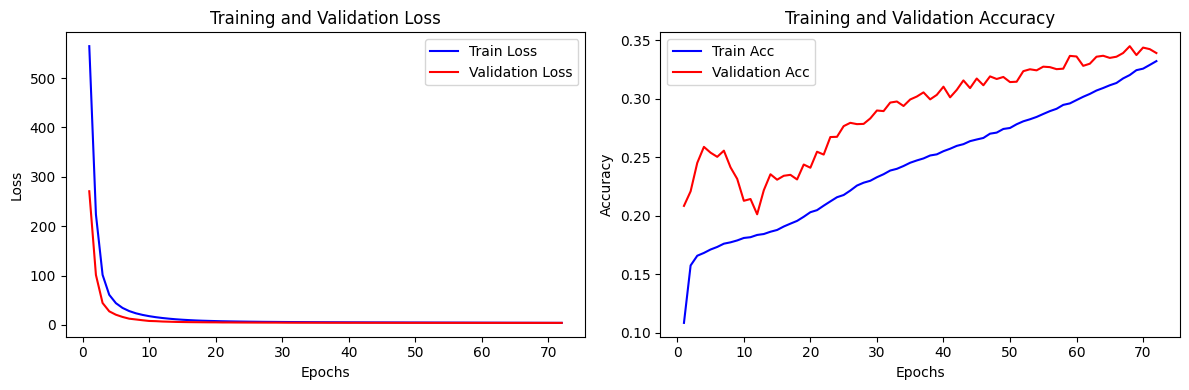

In [67]:
history = checkpoint['history']
plot_history(history)

# 4. inference

In [59]:
def translate_custom(tokens, model, word_to_index, index_to_word):
    """
    tokens: 정수 인코딩이 완료된 단일 시퀀스 (텐서 또는 리스트)
    model: 학습된 Transformer 모델
    word_to_index: 단어 -> ID 딕셔너리
    index_to_word: ID -> 단어 딕셔너리
    """
    # 1. 텐서 상태라면 리스트로 변환
    if hasattr(tokens, 'tolist'):
        tokens = tokens.tolist()
        
    # 2. 패딩 및 길이 고정 (MAX_LEN은 기존에 사용하시던 전역 변수 값 적용)
    if len(tokens) > MAX_LEN:
        tokens = tokens[:MAX_LEN]
    else:
        tokens = tokens + [0] * (MAX_LEN - len(tokens))
    
    # 배치 차원 추가하여 텐서로 변환 [1, MAX_LEN]
    padded_tokens = torch.tensor([tokens], dtype=torch.long, device=DEVICE)

    # 3. 사전에서 특수 토큰 ID 추출 (만약 사전에 없다면 기본값 2, 3번 적용)
    bos_id = word_to_index.get('<sos>', 2)
    eos_id = word_to_index.get('<eos>', 3)

    ids = []
    # 디코더의 첫 입력은 <sos> 토큰으로 시작 [1, 1]
    output = torch.tensor([[bos_id]], dtype=torch.long, device=DEVICE)

    # 4. Autoregressive 디코딩 루프
    for i in range(MAX_LEN):
        # 마스크 생성
        enc_pad_mask, combined_mask, dec_pad_mask = generate_masks(padded_tokens, output)

        # 모델 예측
        with torch.no_grad(): # 예측할 때는 그라디언트 계산 비활성화
            pred_logits, _, _, _ = model(padded_tokens, output, enc_pad_mask, combined_mask, dec_pad_mask)

        # 마지막 시퀀스 위치의 logits에서 가장 확률이 높은 단어 ID 추출
        pred_id = pred_logits[0, -1].argmax(dim=-1).item()

        # 만약 모델이 문장의 끝(<eos>)을 뱉었다면 루프를 종료하고 지금까지 모은 단어 디코딩
        if pred_id == eos_id:
            break
        
        ids.append(pred_id)
        
        # 현재 예측한 단어 ID를 다음 디코더 입력에 이어 붙임
        new_token = torch.tensor([[pred_id]], dtype=torch.long, device=DEVICE)
        output = torch.cat([output, new_token], dim=1)

    # 5. 최종 단어 ID 리스트를 한글 문장으로 복원 (패딩 토큰은 제외)
    result = " ".join([index_to_word[t_id] for t_id in ids if t_id != 0])
    return result

In [60]:
def eval_bleu_single_custom(model, src_tokens, tgt_tokens, word_to_index, index_to_word, verbose=True):
    """
    src_tokens: 정수 인코딩된 단일 질문 시퀀스 (예: enc_test[idx])
    tgt_tokens: 정수 인코딩된 단일 정답 시퀀스 (예: dec_test[idx])
    """
    # 💡 텐서 상태라면 파이썬 리스트로 변환
    if hasattr(src_tokens, 'tolist'): src_tokens = src_tokens.tolist()
    if hasattr(tgt_tokens, 'tolist'): tgt_tokens = tgt_tokens.tolist()

    # 1. 특수 토큰 정의 (패딩=0, <sos>=2, <eos>=3)
    special_tokens = [0, word_to_index.get('<sos>', 2), word_to_index.get('<eos>', 3)]

    # 2. [참조 정답(Ref) 디코딩] 특수 토큰/패딩 제외하고 단어 리스트 형태로 만들기
    ref = [index_to_word[t_id] for t_id in tgt_tokens if t_id not in special_tokens]
    
    # 만약 정답 문장이 너무 짧거나 비어있으면 건너뜁니다
    if len(ref) == 0: return None

    # 3. [모델 예측(Cand) 디코딩] 앞서 만든 Mecab용 translate 함수 활용
    # translate_custom은 한글 '문장 문자열'을 뱉으므로, BLEU를 재기 위해 .split()으로 단어 리스트화합니다.
    pred_sentence = translate_custom(src_tokens, model, word_to_index, index_to_word)
    cand = pred_sentence.split()

    # 4. [원본 질문(Source) 복원] 출력 확인용
    src_sent = " ".join([index_to_word[t_id] for t_id in src_tokens if t_id not in special_tokens])

    # 5. BLEU Score 계산 (smoothing 적용)
    score = sentence_bleu([ref], cand, smoothing_function=SmoothingFunction().method1)

    if verbose:
        print("Source Sentence : ", src_sent)
        print("Model Prediction: ", cand)
        print("Real Target     : ", ref)
        print(f"Score           : {score:.6f}\n" + "-"*50)

    return score

In [61]:
def eval_bleu_custom(model, enc_test_set, dec_test_set, word_to_index, index_to_word, verbose=True):
    """
    enc_test_set: 정수 인코딩된 질문 데이터셋 전체 (예: enc_test)
    dec_test_set: 정수 인코딩된 정답 데이터셋 전체 (예: dec_test)
    """
    total_score = 0.
    valid_samples = 0
    sample_size = len(enc_test_set)

    # 전체 테스트 데이터를 돌며 BLEU 점수 누적
    for idx in tqdm(range(sample_size), desc="Calculating BLEU"):
        score = eval_bleu_single_custom(
            model=model, 
            src_tokens=enc_test_set[idx], 
            tgt_tokens=dec_test_set[idx], 
            word_to_index=word_to_index, 
            index_to_word=index_to_word, 
            verbose=verbose
        )
        
        if score is not None:
            total_score += score
            valid_samples += 1
    
    print("\n" + "="*40)
    print("📊 최종 정량 평가 결과")
    print("========================================")
    print("총 평가 샘플 수   : ", sample_size)
    print("유효 평가 샘플 수 : ", valid_samples)
    print(f"최종 평균 BLEU Score: {total_score / valid_samples if valid_samples > 0 else 0:.6f}")
    print("========================================")

In [62]:
def translate_custom_with_attention(tokens, model, word_to_index, index_to_word):
    if hasattr(tokens, 'tolist'):
        tokens = tokens.tolist()
        
    # 1. 인코더 입력 길이 맞추기
    if len(tokens) > MAX_LEN:
        enc_tokens = tokens[:MAX_LEN]
    else:
        enc_tokens = tokens + [0] * (MAX_LEN - len(tokens))
    
    padded_tokens = torch.tensor([enc_tokens], dtype=torch.long, device=DEVICE)

    bos_id = word_to_index.get('<start>', 2) # 노드 가이드라인 스펙에 맞춰 <start>, <end>로 변경
    eos_id = word_to_index.get('<end>', 3)

    ids = []
    output = torch.tensor([[bos_id]], dtype=torch.long, device=DEVICE)
    
    # 💡 각 디코딩 스텝의 Cross Attention 가중치를 저장할 리스트
    attention_steps = []

    for i in range(MAX_LEN):
        enc_pad_mask, combined_mask, dec_pad_mask = generate_masks(padded_tokens, output)

        with torch.no_grad():
            # 💡 기존 _, _, _ 구조에서 어텐션 맵 리스트를 온전하게 받아옵니다.
            pred_logits, enc_attns, dec_attns, enc_dec_attns = model(
                padded_tokens, output, enc_pad_mask, combined_mask, dec_pad_mask
            )

        pred_id = pred_logits[0, -1].argmax(dim=-1).item()

        # 💡 [핵심] enc_dec_attns에서 마지막 레이어의 어텐션 맵을 가져옵니다.
        # Shape 가정: [batch_size, num_heads, tgt_len, src_len] -> 0번째 배치 선택
        # 여러 레이어 중 '마지막 레이어(-1)'의 '모든 헤드 평균(mean)'을 취하는 것이 직관적입니다.
        last_layer_attn = enc_dec_attns[-1][0] # [num_heads, tgt_len, src_len]
        mean_head_attn = last_layer_attn.mean(dim=0) # [tgt_len, src_len]
        
        # 현재 스텝(가장 마지막에 생성 중인 단어 위치)의 가중치 행만 추출해서 저장
        current_step_attn = mean_head_attn[-1].cpu().numpy() # [src_len]
        attention_steps.append(current_step_attn)

        if pred_id == eos_id:
            break
        
        ids.append(pred_id)
        
        new_token = torch.tensor([[pred_id]], dtype=torch.long, device=DEVICE)
        output = torch.cat([output, new_token], dim=1)

    # 2. 최종 문장 복원
    result_words = [index_to_word[t_id] for t_id in ids if t_id != 0]
    result_sentence = " ".join(result_words)
    
    # 💡 3. 수집된 스텝별 어텐션을 하나의 2D 행렬로 병합 [생성된 단어 수, 입력 단어 수]
    final_attention_matrix = np.array(attention_steps)
    
    # 입력 단어들도 시각화 축에 적어주기 위해 텍스트 리스트로 복원
    source_words = [index_to_word[t_id] for t_id in tokens if t_id != 0]
    
    return result_sentence, final_attention_matrix, source_words, result_words

In [63]:
def plot_attention_map(attention, source_words, target_words):
    """
    attention: [타겟 단어 수, 소스 단어 수] 형태의 넘파이 행렬
    source_words: 인코더 입력 한글 토큰 리스트
    target_words: 디코더 출력 한글 토큰 리스트
    """
    # 한글 깨짐 방지 폰트 설정 (환경에 맞게 나눔고딕/맑은고딕 지정)
    plt.rcParams['font.family'] = 'NanumGothic' # Mac은 'AppleGothic'
    plt.rcParams['axes.unicode_minus'] = False

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(1, 1, 1)
    
    # 크롭 처리: 패딩(0번) 영역을 제외한 실제 단어 길이만큼만 슬라이싱해서 그립니다.
    src_len = len(source_words)
    tgt_len = len(target_words)
    
    # 디코딩 루프 수와 행렬 크기 싱크 조절
    attn_matrix = attention[:tgt_len, :src_len]

    # 히트맵 그리기
    cax = ax.matshow(attn_matrix, cmap='bone')
    fig.colorbar(cax)

    # 축 설정
    ax.set_xticklabels([''] + source_words, rotation=45)
    ax.set_yticklabels([''] + target_words)

    # 매 틱마다 라벨 표시
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.xlabel('질문 (Source)')
    plt.ylabel('대답 (Target)')
    plt.show()

- original test data

In [152]:
VOCAB_SIZE = 6338

In [153]:
loaded_transformer = Transformer(
    n_layers=N_LAYERS,
    emb_dim=EMB_DIM,
    n_heads=N_HEADS,
    ff_dim=FF_DIM,
    src_vocab_size=VOCAB_SIZE,
    tgt_vocab_size=VOCAB_SIZE,
    pos_len=200,
    dropout=0.1,
    shared_fc=True,
    shared_emb=True)

loaded_transformer = loaded_transformer.to(DEVICE)

In [154]:
loaded_model_name = f"best_model-layers-{N_LAYERS}-emb-{EMB_DIM}-HEADS-{N_HEADS}-FF-{FF_DIM}_origin.pt"  # 베스트 모델 가중치를 저장할 파일명
loaded_model_path = os.path.join(MODEL_DIR, loaded_model_name)

In [155]:
# 가장 성능이 좋았던 시점의 가중치 파일 로드
# checkpoint = torch.load("best_transformer_model.pt", map_map=DEVICE)
checkpoint = torch.load(loaded_model_path, map_location=DEVICE)

# 우리 모델 인스턴스에 가중치 덮어씌우기
loaded_transformer.load_state_dict(checkpoint['model_state_dict'])
loaded_transformer.to(DEVICE)
loaded_transformer.eval()  # 평가 모드 전환

print(f"🎯 {checkpoint['epoch']}에폭 기준, 가장 손실이 낮았던({checkpoint['best_loss']:.4f}) 가중치를 성공적으로 불러왔습니다.")

# 이후 아까 만들어둔 translate_custom 함수로 테스트 진행하시면 됩니다!

🎯 188에폭 기준, 가장 손실이 낮았던(4.1041) 가중치를 성공적으로 불러왔습니다.


In [156]:
origin_data = torch.load(os.path.join(DATA_DIR, "encoded_test_origin.pt"))
origin_data.keys()

dict_keys(['origin_test_q', 'origin_test_a'])

In [157]:
origin_enc_test = origin_data['origin_test_q']
origin_dec_test = origin_data['origin_test_a']

In [158]:
origin_enc_test[0]

tensor([   2, 1175,    1,   32,   77,  277,  126, 5033,   19,    3,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0])

In [164]:
idx = random.randint(0, len(origin_enc_test) - 1)

origin_test_question_tokens = origin_enc_test[idx]
origin_test_answer_tokens = origin_dec_test[idx]

predicted_string = translate_custom(
    tokens=origin_test_question_tokens,
    model=loaded_transformer,
    word_to_index=word_to_index,
    index_to_word=index_to_word
)

# 4. 화면 비교 출력을 위해 원래 질문과 실제 정답 토큰들도 한글 문자열로 복원
# (특수 토큰인 패딩(0), <sos>, <eos>는 지우고 순수 단어만 이어 붙입니다.)
special_tokens = [0, word_to_index.get('<sos>', 2), word_to_index.get('<eos>', 3)]

question_string = " ".join([index_to_word[t_id.item()] for t_id in origin_test_question_tokens if t_id.item() not in special_tokens])
gt_answer_string = " ".join([index_to_word[t_id.item()] for t_id in origin_test_answer_tokens if t_id.item() not in special_tokens])

# 5. 최종 결과 확인
print(f"🎯 테스트 데이터 인덱스: {idx}")
print(f"💬 원본 질문 (Test Input)   : {question_string}")
print(f"✨ 실제 정답 (Gold Target)   : {gt_answer_string}")
print(f"🔮 모델의 답변 (Prediction)  : {predicted_string}")

🎯 테스트 데이터 인덱스: 592
💬 원본 질문 (Test Input)   : 이 좋 은 날
✨ 실제 정답 (Gold Target)   : 좋 은 생각 만 나 면 좋 을 텐데
🔮 모델의 답변 (Prediction)  : 좋 은 생각 해 보 세요


- 정량 평가

In [165]:
eval_bleu_custom(
    model=loaded_transformer, 
    enc_test_set=origin_enc_test, 
    dec_test_set=origin_dec_test, 
    word_to_index=word_to_index, 
    index_to_word=index_to_word, 
    verbose=False  # 실시간 매칭 상태 확인용
)

Calculating BLEU:   0%|          | 0/1175 [00:00<?, ?it/s]


📊 최종 정량 평가 결과
총 평가 샘플 수   :  1175
유효 평가 샘플 수 :  1175
최종 평균 BLEU Score: 0.021922


- 정성 평가

💡 질문 토큰들: ['<bos>', '애매', '<unk>', '한', '썸', '그냥', '끝', '낼까', '?', '<eos>']
🤖 챗봇 답변: 사랑 을 갖 고 좋 은 사람 마다 다르 겠 어요


/tmp/ipykernel_1276844/3821895968.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + source_words, rotation=45)
/tmp/ipykernel_1276844/3821895968.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + target_words)


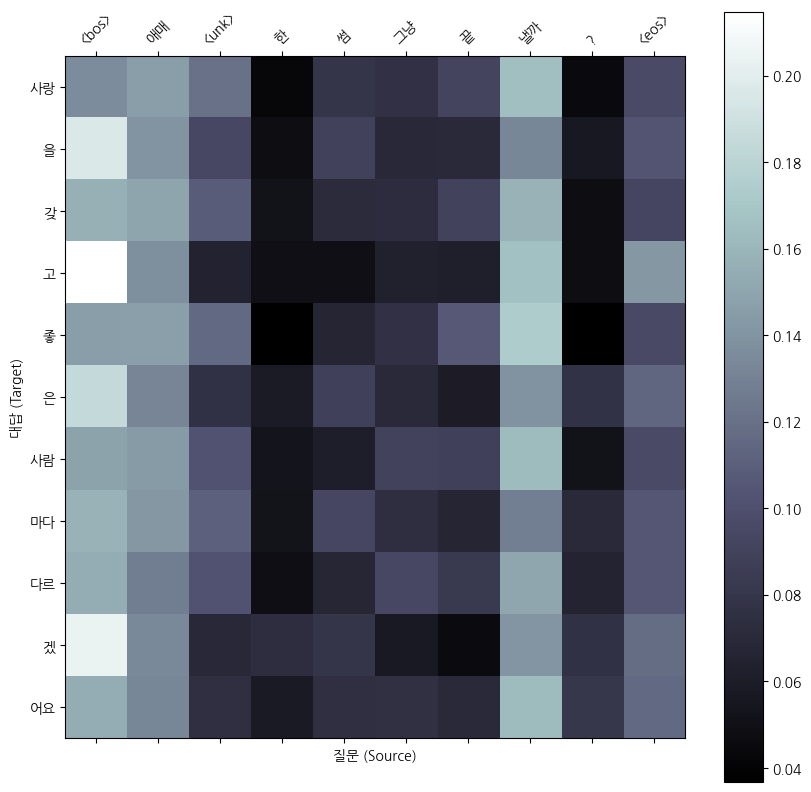

In [167]:
# 1. 테스트셋에서 샘플 하나 인코딩 덩어리 가져오기
sample_tokens = enc_test_seq[0] 

# 2. 어텐션 행렬과 함께 번역(답변 생성) 수행
pred_sentence, attn_mat, src_w, tgt_w = translate_custom_with_attention(
    sample_tokens, loaded_transformer, word_to_index, index_to_word
)

print("💡 질문 토큰들:", src_w)
print("🤖 챗봇 답변:", pred_sentence)

# 3. 그래프 그리기
plot_attention_map(attn_mat, src_w, tgt_w)

- 전반적으로 호응도 안 맞고 단어 생성 시에도 관련있는 단어가 생성됐다고 보기 어려움

- augmentation 수행 시

In [64]:
VOCAB_SIZE = 7502

In [79]:
loaded_transformer = Transformer(
    n_layers=N_LAYERS,
    emb_dim=EMB_DIM,
    n_heads=N_HEADS,
    ff_dim=FF_DIM,
    src_vocab_size=VOCAB_SIZE,
    tgt_vocab_size=VOCAB_SIZE,
    pos_len=200,
    dropout=0.1,
    shared_fc=True,
    shared_emb=True)

loaded_transformer = loaded_transformer.to(DEVICE)

In [80]:
loaded_model_name = f"best_model-layers-{N_LAYERS}-emb-{EMB_DIM}-HEADS-{N_HEADS}-FF-{FF_DIM}_aug.pt"  # 베스트 모델 가중치를 저장할 파일명
loaded_model_path = os.path.join(MODEL_DIR, loaded_model_name)

In [81]:
# 가장 성능이 좋았던 시점의 가중치 파일 로드
# checkpoint = torch.load("best_transformer_model.pt", map_map=DEVICE)
checkpoint = torch.load(loaded_model_path, map_location=DEVICE)

# 우리 모델 인스턴스에 가중치 덮어씌우기
loaded_transformer.load_state_dict(checkpoint['model_state_dict'])
loaded_transformer.to(DEVICE)
loaded_transformer.eval()  # 평가 모드 전환

print(f"🎯 {checkpoint['epoch']}에폭 기준, 가장 손실이 낮았던({checkpoint['best_loss']:.4f}) 가중치를 성공적으로 불러왔습니다.")

# 이후 아까 만들어둔 translate_custom 함수로 테스트 진행하시면 됩니다!

🎯 72에폭 기준, 가장 손실이 낮았던(4.0729) 가중치를 성공적으로 불러왔습니다.


In [82]:
# 어휘 사전 불러오기
saved_aug_vocab_data = torch.load(os.path.join(DATA_DIR, "save_aug_vocab_data.pt"))
aug_idx_to_word, aug_word_to_idx = saved_aug_vocab_data['index_to_word'], saved_aug_vocab_data['word_to_index']
print(len(aug_idx_to_word), len(aug_idx_to_word))

7502 7502


In [83]:
# 저장된 데이터 불러오기
test_aug_data = torch.load(os.path.join(DATA_DIR, 'encoded_test_aug.pt'))
test_aug_data.keys()

dict_keys(['train_q', 'train_a'])

In [84]:
# test data는 그대로지만 augmentation된 train data 기반 토크나이저로 토큰화했기 때분에 별도 관리 필요
enc_test_aug, dec_test_aug = test_aug_data['train_q'], test_aug_data['train_a']
print(len(enc_test_aug), len(dec_test_aug))

1175 1175


In [85]:
idx = random.randint(0, len(enc_test_aug) - 1)

test_question_tokens = enc_test_aug[idx]
test_answer_tokens = dec_test_aug[idx]

# Mecab 전용 translate 함수 호출
predicted_string = translate_custom(
    tokens=test_question_tokens,
    model=loaded_transformer,
    word_to_index=aug_word_to_idx,
    index_to_word=aug_idx_to_word
)

# 4. 화면 비교 출력을 위해 원래 질문과 실제 정답 토큰들도 한글 문자열로 복원
# (특수 토큰인 패딩(0), <sos>, <eos>는 지우고 순수 단어만 이어 붙입니다.)
special_tokens = [0, word_to_index.get('<sos>', 2), word_to_index.get('<eos>', 3)]

question_string = " ".join([index_to_word[t_id.item()] for t_id in test_question_tokens if t_id.item() not in special_tokens])
gt_answer_string = " ".join([index_to_word[t_id.item()] for t_id in test_answer_tokens if t_id.item() not in special_tokens])

# 5. 최종 결과 확인
print(f"🎯 테스트 데이터 인덱스: {idx}")
print(f"💬 원본 질문 (Test Input)   : {question_string}")
print(f"✨ 실제 정답 (Gold Target)   : {gt_answer_string}")
print(f"🔮 모델의 답변 (Prediction)  : {predicted_string}")

🎯 테스트 데이터 인덱스: 686
💬 원본 질문 (Test Input)   : 인정받 으려면 어떻게 해야 하나
✨ 실제 정답 (Gold Target)   : 지금 도 충분히 잘 하 고 있 어요
🔮 모델의 답변 (Prediction)  : 스스로 하 고 있 을 거 예요


In [86]:
# verbose=True로 두면 1만 개 데이터 로그가 다 찍히니, 
# 처음 10~20개만 True로 모니터링해 보신 뒤 전체 평가는 False로 돌리는 걸 추천합니다.
eval_bleu_custom(
    model=loaded_transformer, 
    enc_test_set=enc_test_aug, 
    dec_test_set=dec_test_aug, 
    word_to_index=aug_word_to_idx, 
    index_to_word=aug_idx_to_word, 
    verbose=False  # 실시간 매칭 상태 확인용
)

Calculating BLEU:   0%|          | 0/1175 [00:00<?, ?it/s]


📊 최종 정량 평가 결과
총 평가 샘플 수   :  1175
유효 평가 샘플 수 :  1175
최종 평균 BLEU Score: 0.026857


augmentation 적용 후: 0.021922  
augmentation 적용 후: 0.026857  
augmentation 적용 후 소폭 상승

💡 질문 토큰들: ['<bos>', '애매', '<unk>', '한', '썸', '그냥', '끝', '낼까', '?', '<eos>']
 정답:  직접 적 으로 들이대 보 세요
🤖 챗봇 답변: 카페인 이 찾아올 거 예요


/tmp/ipykernel_1281787/3821895968.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + source_words, rotation=45)
/tmp/ipykernel_1281787/3821895968.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + target_words)


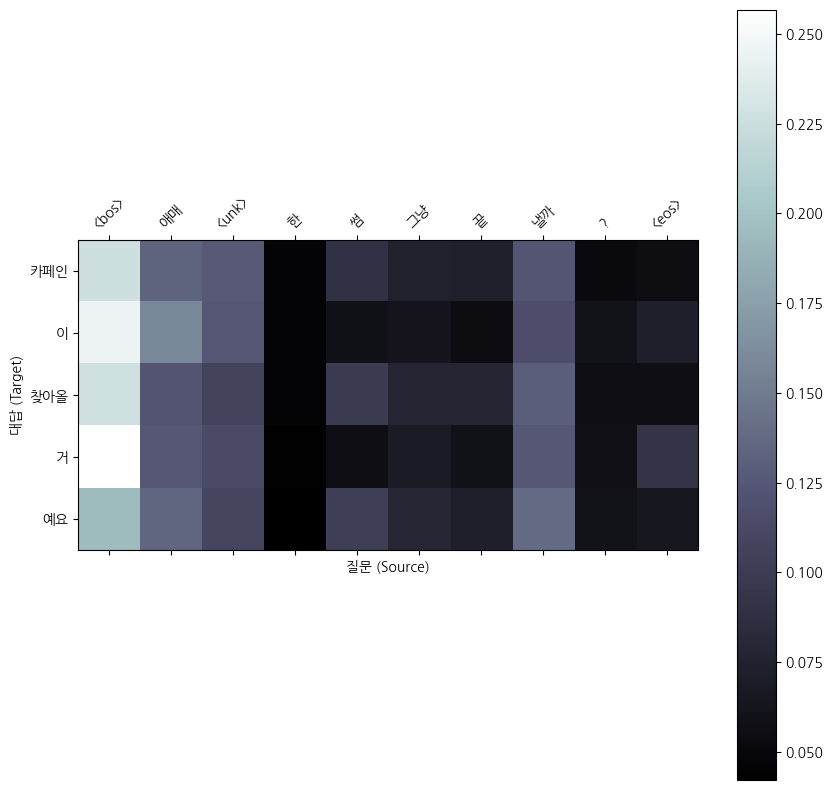

In [89]:
# 1. 테스트셋에서 샘플 하나 인코딩 덩어리 가져오기
sample_tokens = enc_test_aug[0] 
smaple_answer_tokens = dec_test_aug[0]

# 2. 어텐션 행렬과 함께 번역(답변 생성) 수행
pred_sentence, attn_mat, src_w, tgt_w = translate_custom_with_attention(
    sample_tokens, loaded_transformer, aug_word_to_idx, aug_idx_to_word
)
special_tokens = [0, aug_word_to_idx.get('<sos>', 2), aug_word_to_idx.get('<eos>', 3)]
gt_answer_string = " ".join([aug_idx_to_word[t_id.item()] for t_id in smaple_answer_tokens if t_id.item() not in special_tokens])

print("💡 질문 토큰들:", src_w)
print(" 정답: ", gt_answer_string)
print("🤖 챗봇 답변:", pred_sentence)

# 3. 그래프 그리기
plot_attention_map(attn_mat, src_w, tgt_w)

- "찾아올 거예요" 같은 문장을 생성해서 의미상 호응을 이루는 것 같으나, "카페인" 같은 이상한 단어가 들어감
- 썸 -> 찾아올 과 같이 어느 정도 호응이 맞는 단어를 예측하는 것 같으나 전체적으로는 의미를 파악하지 못하고 있는 것으로 보임

# 회고

- 전처리 시 data split을 마지막에 수행하였는데, augmentation을 할 때 상당한 어려움을 겪어서 결국 다시 뒤엎었다. 각 작업의 순서를 구성할 때 어떤 문제가 발생할 수 있을지, 개괄적인 시선으로 먼저 바라보고 고민해야 함을 느꼈다.    
- 이번 프로젝트를 하면서 토크나이저를 학습하거나 augmentation을 수행할 때, data leakage를 방지하기 위해 철저히 validaton, test dataset을 구분하는 것에 대해 좀더 배울 수 있었다.  